
# Voronoi map greedy four-color animation
Generates a random Voronoi map from k seed points, builds the planar adjacency, greedy-colors it with up to four colors, and animates the step-by-step coloring.


In [16]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, colors as mcolors
from matplotlib.collections import PolyCollection
from scipy.spatial import Voronoi

rng = np.random.default_rng(4)
palette = ["#af33f2", "#3933f2", "#fc88fc", "#58e8dc"]


In [2]:

# Geometry helpers: bounded Voronoi cells and clipping to the unit square.
def voronoi_finite_polygons_2d(vor, radius=None):
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")
    if radius is None:
        radius = vor.points.ptp().max() * 2
    new_regions = []
    new_vertices = vor.vertices.tolist()
    center = vor.points.mean(axis=0)
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))
    for p1, region_index in enumerate(vor.point_region):
        vertices = vor.regions[region_index]
        if -1 not in vertices:
            new_regions.append(vertices)
            continue
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]
        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0 and v2 >= 0:
                continue
            tangent = vor.points[p2] - vor.points[p1]
            tangent /= np.linalg.norm(tangent)
            normal = np.array([-tangent[1], tangent[0]])
            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, normal)) * normal
            far_point = vor.vertices[v2] + direction * radius
            new_vertices.append(far_point.tolist())
            new_region.append(len(new_vertices) - 1)
        verts = np.asarray([new_vertices[v] for v in new_region])
        centroid = verts.mean(axis=0)
        angles = np.arctan2(verts[:, 1] - centroid[1], verts[:, 0] - centroid[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]
        new_regions.append(new_region)
    return new_regions, np.asarray(new_vertices)


def _clip_edge(points, inside, intersect):
    if not points:
        return []
    output = []
    pairs = zip(points, points[1:] + points[:1])
    for p1, p2 in pairs:
        p1_in, p2_in = inside(p1), inside(p2)
        if p2_in:
            if not p1_in:
                output.append(intersect(p1, p2))
            output.append(p2)
        elif p1_in:
            output.append(intersect(p1, p2))
    return output


def clip_polygon(poly, bounds=(0.0, 1.0, 0.0, 1.0)):
    xmin, xmax, ymin, ymax = bounds
    pts = poly.tolist()
    pts = _clip_edge(pts, lambda p: p[0] >= xmin, lambda p1, p2: [xmin, p1[1] + (p2[1] - p1[1]) * (xmin - p1[0]) / (p2[0] - p1[0])])
    pts = _clip_edge(pts, lambda p: p[0] <= xmax, lambda p1, p2: [xmax, p1[1] + (p2[1] - p1[1]) * (xmax - p1[0]) / (p2[0] - p1[0])])
    pts = _clip_edge(pts, lambda p: p[1] >= ymin, lambda p1, p2: [p1[0] + (p2[0] - p1[0]) * (ymin - p1[1]) / (p2[1] - p1[1]), ymin])
    pts = _clip_edge(pts, lambda p: p[1] <= ymax, lambda p1, p2: [p1[0] + (p2[0] - p1[0]) * (ymax - p1[1]) / (p2[1] - p1[1]), ymax])
    return np.asarray(pts)


def build_adjacency(vor):
    adj = {i: set() for i in range(len(vor.points))}
    for a, b in vor.ridge_points:
        adj[a].add(b)
        adj[b].add(a)
    return adj


In [3]:

# Greedy 4-coloring with backtracking to keep within the four-color bound.
def greedy_four_color(adj, max_colors=4):
    order = sorted(adj, key=lambda n: len(adj[n]), reverse=True)
    colors = {n: None for n in adj}
    steps = []

    def backtrack(i):
        if i == len(order):
            return True
        node = order[i]
        used = {colors[n] for n in adj[node] if colors[n] is not None}
        for c in range(max_colors):
            if c in used:
                continue
            colors[node] = c
            steps.append({"node": node, "color": c, "complete": dict(colors)})
            if backtrack(i + 1):
                return True
        colors[node] = None
        return False

    backtrack(0)
    return colors, steps


In [4]:

# Plotting and animation utilities.
def plot_map(polygons, points, colors, palette, title=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    for idx, poly in enumerate(polygons):
        face = palette[colors[idx]] if colors.get(idx) is not None else "#dddddd"
        ax.fill(poly[:, 0], poly[:, 1], facecolor=face, edgecolor="#333", linewidth=0.6)
    ax.scatter(points[:, 0], points[:, 1], s=15, c="#111", zorder=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.show()





In [5]:
def _extract_successful_run(steps, final_colors):
    """Return ordered steps for the successful coloring (one per region)."""
    seen = set()
    run = []
    for step in reversed(steps):
        node = step.get("node")
        color = step.get("color")
        if color is None or node in seen:
            continue
        # only keep steps that match the final coloring to drop earlier failed attempts
        if node in final_colors and step.get("complete", {}).get(node) == final_colors[node]:
            seen.add(node)
            run.append(step)
        if len(seen) == len(final_colors):
            break
    run.reverse()
    if len(run) != len(final_colors):
        raise ValueError("Could not extract a full successful run from provided steps.")
    return run

def animate_coloring(polygons, points, adj_or_steps, palette, tries=400, base_color="#f1f1f1", rng=None):
    """Find a greedy 4-coloring and animate adding one region at a time.

    adj_or_steps: adjacency dict (preferred) or steps from greedy_four_color.
    Returns (anim, colors, order) where order matches the successful run.
    """
    if rng is None:
        rng = np.random.default_rng()

    if isinstance(adj_or_steps, dict):
        adj = adj_or_steps
        colors, steps, order, _ = greedy_four_color(adj, max_colors=4, tries=tries, rng=rng)
        steps = _extract_successful_run(steps, colors)
        order = [s["node"] for s in steps]
    else:
        colored_steps = [s for s in adj_or_steps if s.get("color") is not None]
        if not colored_steps:
            raise ValueError("Steps list is empty; pass adjacency instead to recompute.")
        final_colors = colored_steps[-1]["complete"]
        steps = _extract_successful_run(colored_steps, final_colors)
        colors = steps[-1]["complete"]
        order = [s["node"] for s in steps]

    base = np.tile(np.array(mcolors.to_rgba(base_color)), (len(polygons), 1))
    frames = [base]
    current = base.copy()
    for step in steps:
        node = step["node"]
        color = step.get("color")
        current = current.copy()
        current[node] = mcolors.to_rgba(palette[color])
        frames.append(current)

    fig, ax = plt.subplots(figsize=(6, 6))
    coll = PolyCollection(polygons, closed=True, edgecolor="#333", linewidth=0.6)
    coll.set_facecolor(base)
    ax.add_collection(coll)
    #ax.scatter(points[:, 0], points[:, 1], s=15, c="#111", zorder=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    title = ax.text(0.02, 1.02, "Uncolored map", transform=ax.transAxes)

    def update(i):
        coll.set_facecolor(frames[i])
        if i == 0:
            title.set_text("Uncolored map")
        else:
            node = order[i - 1]
            title.set_text(f"Region {node} -> color {colors[node] + 1}")
        return coll, title

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=600, blit=True)
    plt.close(fig)
    return anim, colors, order


regions: 50
steps taken: 3188629


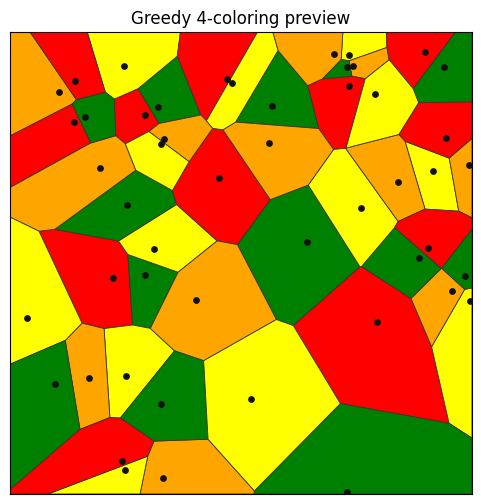

In [47]:

# Generate a random map and build adjacency.
k = 50  # change for more/fewer regions
points = rng.random((k, 2))
vor = Voronoi(points)
regions, vertices = voronoi_finite_polygons_2d(vor, radius=2.0)
polygons = [clip_polygon(vertices[region]) for region in regions]
adj = build_adjacency(vor)
colors, steps = greedy_four_color(adj)
print(f"regions: {len(polygons)}")
print(f"steps taken: {len(steps)}")
plot_map(polygons, points, colors, palette, title="Greedy 4-coloring preview")


In [48]:
# Animate the step-by-step coloring.
anim,colors,order = animate_coloring(polygons, points, steps, palette)
from IPython.display import HTML
HTML(anim.to_jshtml())


In [13]:
sorted(order)

[0,
 1,
 3,
 10,
 13,
 15,
 16,
 17,
 18,
 21,
 22,
 23,
 24,
 25,
 26,
 26,
 31,
 34,
 34,
 35,
 35,
 35,
 35,
 35,
 35,
 37,
 37,
 37,
 37,
 37,
 37,
 40,
 40,
 40,
 40,
 40,
 40,
 41,
 41,
 41,
 41,
 41,
 41,
 44,
 44,
 44,
 44,
 45,
 46,
 46]

In [16]:
len(order)

50

In [40]:
def animate_horizontal_stripes(k, palette, base_color="#f1f1f1", interval=450):
    """Animate painting k horizontal stripes with colors from palette."""
    if k <= 0:
        raise ValueError("k must be positive")
    if not palette:
        raise ValueError("palette must contain at least one color")

    palette_rgba = [mcolors.to_rgba(c) for c in palette]
    y = np.linspace(1, 0, k + 1)  # start at the top edge (y=1)
    stripes = [
        np.array([[0, y[i + 1]], [1, y[i + 1]], [1, y[i]], [0, y[i]]])
        for i in range(k)
    ]

    base = np.tile(np.array(mcolors.to_rgba(base_color)), (k, 1))
    frames = [base]
    for i in range(k):
        frame = frames[-1].copy()
        frame[i] = palette_rgba[i % len(palette_rgba)]
        frames.append(frame)

    fig, ax = plt.subplots(figsize=(6, 6))
    coll = PolyCollection(stripes, closed=True, edgecolor="#333", linewidth=0.6)
    coll.set_facecolor(base)
    ax.add_collection(coll)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    title = ax.text(0.02, 1.02, "Uncolored stripes", transform=ax.transAxes)

    def update(i):
        coll.set_facecolor(frames[i])
        if i == 0:
            title.set_text("Uncolored stripes")
        else:
            title.set_text(f"Stripe {i} colored (top to bottom)")
        return coll, title

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=True)
    plt.close(fig)
    return anim


In [43]:
palette=["red","orange","yellow","green","blue","purple","pink"]

In [44]:
stripe_anim = animate_horizontal_stripes(k=len(palette), palette=palette)
HTML(stripe_anim.to_jshtml())